In [72]:
import kagglehub
from pandas import to_numeric

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\MICROSOFT\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [112]:
# Data understanding
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
# model explainability
import shap

warnings.filterwarnings("ignore")

In [74]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [75]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Number of rows: 7043
Number of columns: 21


In [76]:
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [77]:
# check missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [78]:
# get unique values
print(df.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


`customerID` is a unique identifier for each customer, so it can be dropped from the analysis.

In [79]:
# drop customerID
df.drop("customerID", axis=1, inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data cleaning

In [80]:
# convert datatypes
print(df.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [81]:
print(df.nunique())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [82]:
print(df["PaymentMethod"].value_counts()) # test other features

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [83]:
# encode categorical variables using OneHotEncoder because the columns are not ordinal so we don't use LabelEncoder
numeric_col = ["tenure", "MonthlyCharges", "TotalCharges"] # tenure = Number of months the customer has stayed with the company

categorical_col = [col for col in df.columns if col not in numeric_col + ["Churn"]]
print("Numeric columns:", numeric_col)
print("Categorical columns:", categorical_col)

Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [84]:
# encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_col, drop_first=True)
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,No,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.5,No,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,Yes,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,No,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,Yes,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


# EDA

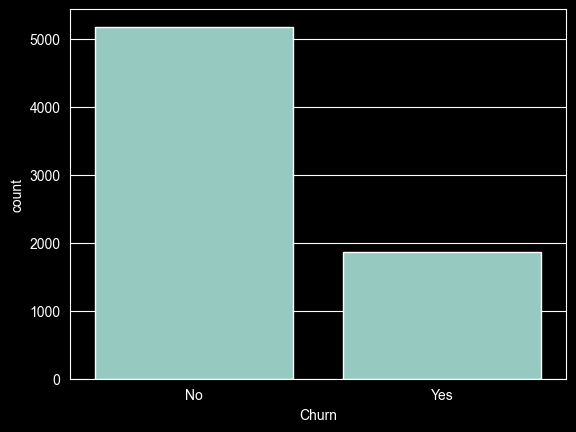

In [85]:
# churn destribution
sns.countplot(x="Churn", data=df_encoded)
plt.show()

Distribution of `churn` is imbalanced, so when splitting the data into training and testing sets, we should use **stratified** sampling to ensure that the proportion of churned and non-churned customers is maintained in both sets.

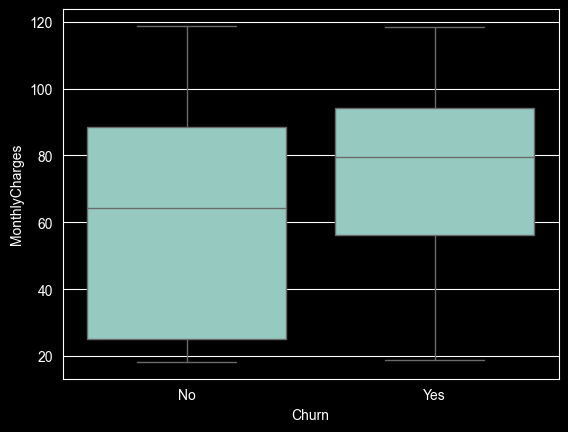

In [86]:
# Monthly charges vs churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_encoded)
plt.show()

when `MonthlyCharges` is higher, customers are more likely to churn. This could be because higher charges may lead to dissatisfaction, prompting customers to leave the service.

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


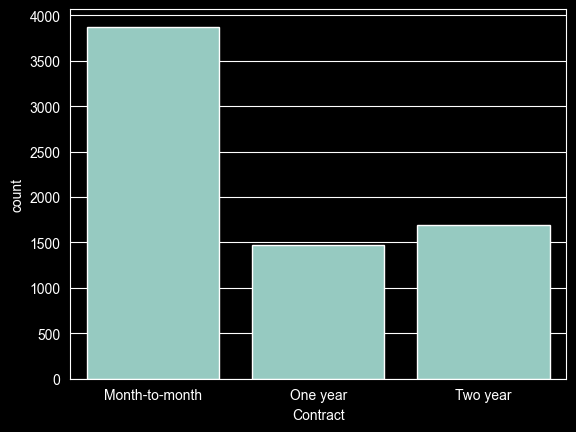

In [87]:
print(df["Contract"].value_counts())
sns.countplot(x="Contract", data=df)
plt.show()

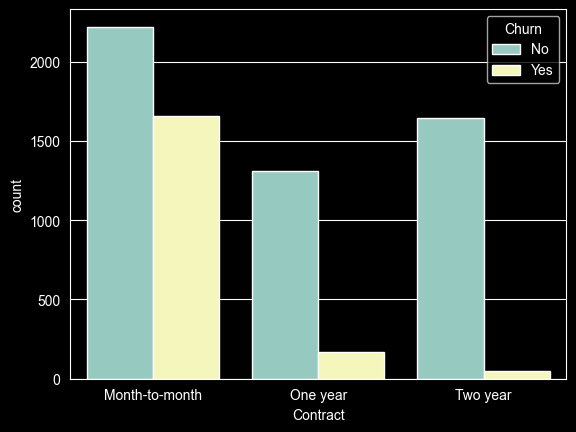

In [88]:
# visualize the relationship between `Contract` and `Churn`
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

Customers with Month-to-Month contracts are more likely to churn compared to those with One Year or Two Year contracts. This could be because customers with longer-term contracts may have more incentives to stay, such as discounts or penalties for early termination.

## Feature engineering

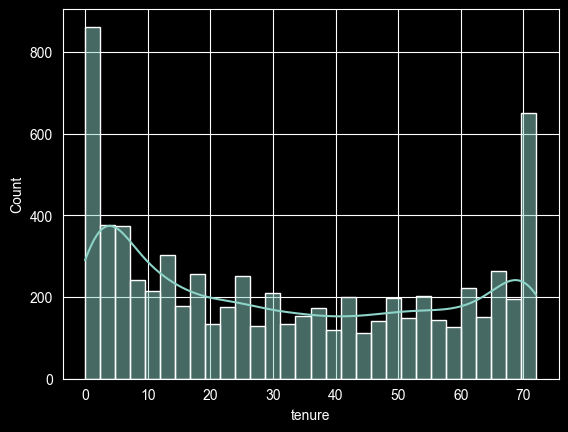

In [89]:
# Tenure groups (old vs new)
# first get the distribution of tenure
sns.histplot(df_encoded["tenure"], bins=30, kde=True)
plt.show()

In [90]:
# create tenure groups based on the distribution
df_encoded["tenure_group"] = pd.cut(df_encoded["tenure"], bins=[0, 10, 50, 72], labels=["new", "medium", "old"])
print(df_encoded["tenure_group"].value_counts())

tenure_group
medium    2968
old       2105
new       1959
Name: count, dtype: int64


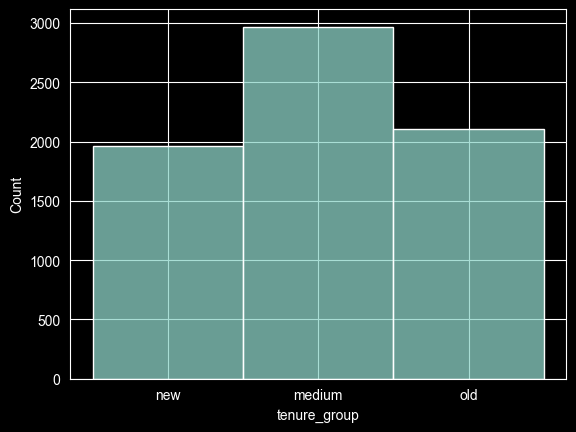

In [91]:
sns.histplot(df_encoded["tenure_group"], bins=30, kde=False)
plt.show()

In [92]:
print(df_encoded[numeric_col].dtypes)

tenure              int64
MonthlyCharges    float64
TotalCharges          str
dtype: object


In [93]:
# convert TotalCharges --> float
df_encoded["TotalCharges"] = pd.to_numeric(df_encoded["TotalCharges"], errors="coerce")
print(df_encoded[df_encoded["TotalCharges"].isna()])

      tenure  MonthlyCharges  TotalCharges Churn  gender_Male  \
488        0           52.55           NaN    No        False   
753        0           20.25           NaN    No         True   
936        0           80.85           NaN    No        False   
1082       0           25.75           NaN    No         True   
1340       0           56.05           NaN    No        False   
3331       0           19.85           NaN    No         True   
3826       0           25.35           NaN    No         True   
4380       0           20.00           NaN    No        False   
5218       0           19.70           NaN    No         True   
6670       0           73.35           NaN    No        False   
6754       0           61.90           NaN    No         True   

      SeniorCitizen_1  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
488             False         True            True             False   
753             False        False            True              True   
936

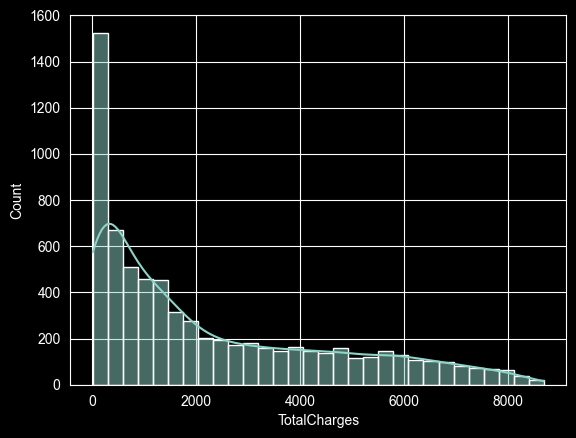

In [94]:
sns.histplot(df_encoded["TotalCharges"], bins=30, kde=True)
plt.show()

In [95]:
# drop the missing values
df_encoded.dropna(subset=["TotalCharges"], inplace=True)

print(df_encoded["TotalCharges"].isna().sum())

0


In [96]:
# scale numeric features
scaler = MinMaxScaler()
df_encoded[numeric_col] = scaler.fit_transform(df_encoded[numeric_col])
print(df_encoded[numeric_col].head())

     tenure  MonthlyCharges  TotalCharges
0  0.000000        0.115423      0.001275
1  0.464789        0.385075      0.215867
2  0.014085        0.354229      0.010310
3  0.619718        0.239303      0.210241
4  0.014085        0.521891      0.015330


In [97]:
print(df_encoded.dtypes)

tenure                                    float64
MonthlyCharges                            float64
TotalCharges                              float64
Churn                                         str
gender_Male                                  bool
SeniorCitizen_1                              bool
Partner_Yes                                  bool
Dependents_Yes                               bool
PhoneService_Yes                             bool
MultipleLines_No phone service               bool
MultipleLines_Yes                            bool
InternetService_Fiber optic                  bool
InternetService_No                           bool
OnlineSecurity_No internet service           bool
OnlineSecurity_Yes                           bool
OnlineBackup_No internet service             bool
OnlineBackup_Yes                             bool
DeviceProtection_No internet service         bool
DeviceProtection_Yes                         bool
TechSupport_No internet service              bool


In [98]:
# convert churn to binary int
df_encoded["Churn"] = df_encoded["Churn"].map({"Yes": 1, "No": 0})
print(df_encoded["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [99]:
# convert tenure_group to dummy variables
df_encoded = pd.get_dummies(df_encoded, columns=["tenure_group"], drop_first=True)
print(df_encoded.dtypes)

tenure                                   float64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
SeniorCitizen_1                             bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

## Model training

In [100]:
# split the data into training and testing sets using stratified sampling
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype(float)
X_test = X_test.astype(float)
print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 5625
Testing set size: 1407


In [101]:
# Baseline model using Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



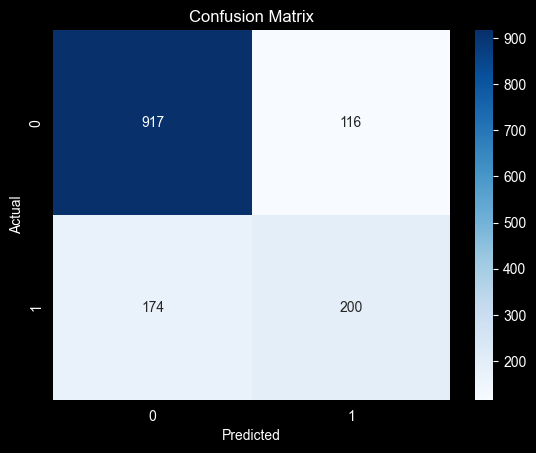

In [102]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [115]:
# save this model
import os
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(lr, 'models/logistic_model.pkl')

['models/logistic_model.pkl']

In [103]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# classification report
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



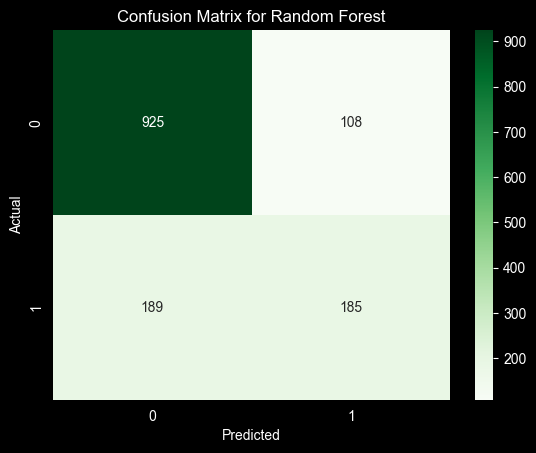

In [104]:
# confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Random Forest")
plt.show()

In [105]:
# XGBoost Classifier
from xgboost import XGBClassifier
xgbclf = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgbclf.fit(X_train, y_train)
y_pred_xgb = xgbclf.predict(X_test)


Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



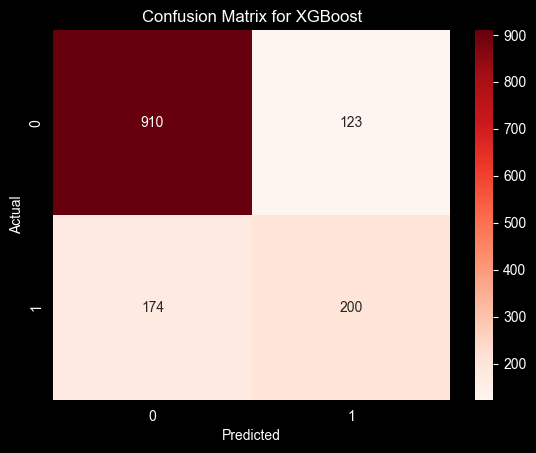

In [106]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# confusion matrix for XGBoost
cm_rf = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for XGBoost")
plt.show()

the logistic Regression model is the best model

# Model explainability

In [107]:
explainer = shap.Explainer(lr, X_train)
shap_values = explainer(X_test)

what features drive to churn?

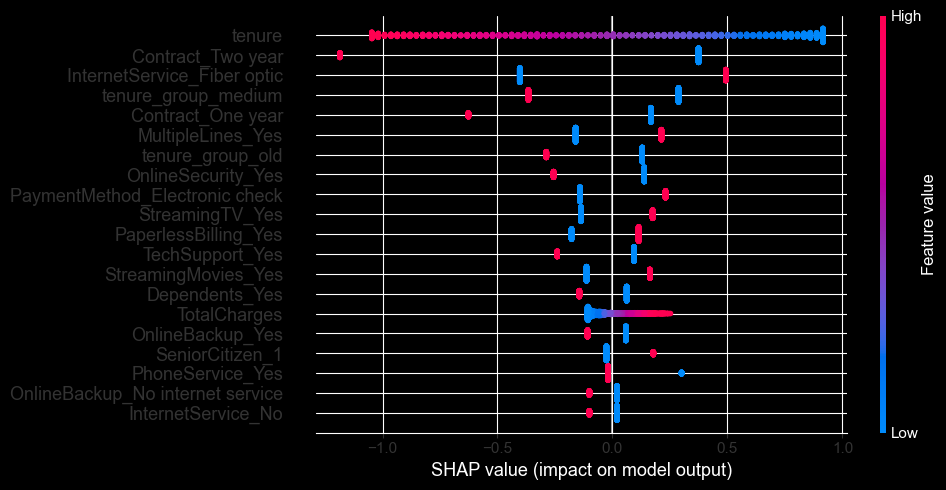

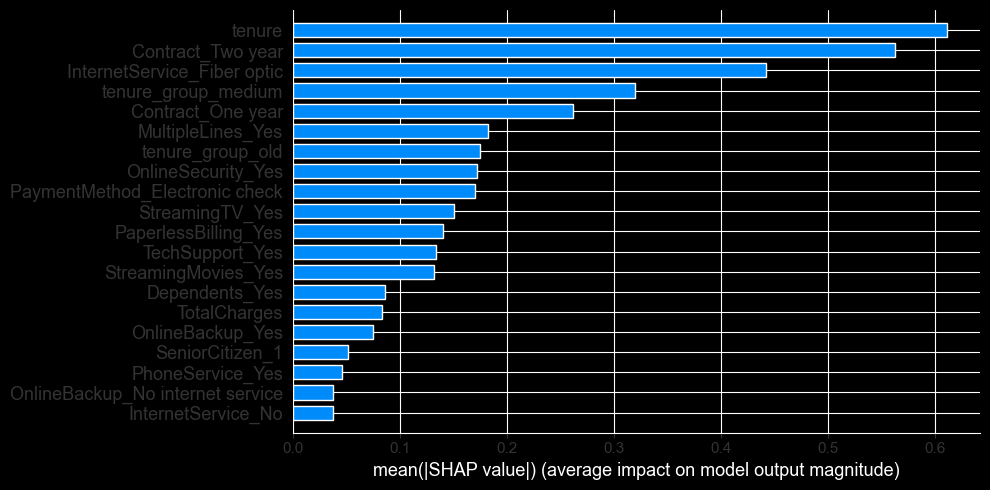

In [111]:
shap.summary_plot(shap_values, X_test, plot_size=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size=(10, 5))

## 2. Top drivers of churn

From the plot:

1. **tenure**
    - Red (high tenure) → negative SHAP → less likely to churn
    - Blue (low tenure) → positive SHAP → more likely to churn
        - **Insight**: New customers are at highest risk.
2. **Contract_Two year**
    - Red (1 → has two-year contract) → negative SHAP → reduces churn
        - **Insight**: Long-term contracts reduce churn.
3. **InternetService_Fiber optic**
    - Red (high → customer has fiber) → slightly increases churn
        - **Insight**: Fiber customers churn slightly more, maybe due to cost/expectations.
4. **tenure_group_medium / Contract_One year / MultipleLines_Yes**
    - Mixed **effects**: medium tenure reduces churn compared to very short, but one-year contracts can slightly increase churn compared to two-year.
5. **PaymentMethod_Electronic check**
    - Red → increases churn
        - **Insight**: Certain payment methods have higher churn risk.
                -
                        -
---

The SHAP analysis reveals that `tenure` is the most important driver of churn: customers with low tenure are more likely to leave, while long-term customers stay. `Two-year contracts` strongly reduce churn, whereas `electronic check payment` and `fiber optic internet` slightly increase churn probability. Additional services like `tech support` or `streaming` have smaller but noticeable effects, indicating that bundling services could help retain customers